## **Final Project: One Anomaly, Defended**
### **Team 16:** Sofía Fariña and Martina Retamales
### **Course: IELE756 – Preparación y Análisis de Datos**
### Link GitHub: https://github.com/ICI-SofiaFV/IELE756-FinalProject
### Link Video: https://youtu.be/K2IFgJ8BCNQ

## **Anomaly proposal**

**1. ¿Cuál es la anomalía, en una sola frase?** San Pedro registra una tasa de notificación ENO de aproximadamente 609 casos por 10.000 habitantes, más de 6 desviaciones estándar sobre la media regional, a pesar de tener una proporción de población extranjera moderada (11.3%) y una población total pequeña (11.108 habitantes).

**2.¿Dónde se encuentra?: ¿en qué comuna(s), qué variable(s), qué celda de figura o tabla de tus cuadernos de Tarea 1, 2 o 3?** La anomalía aparece en la Tarea 3 (Parte 1.2) donde San Pedro queda etiquetado como el outlier más extremo de la muestra. La variable afectada es eno_rate_per_10k del df_clean (38 comunas tras limpieza). San Pedro tiene el residuo OLS más alto de todos los puntos del gráfico.

**3.¿Por qué es sorprendente? ¿Qué habrías predicho y cuánto difiere el valor observado?** El modelo demográfico predice tasas ENO más altas en comunas con alta proporción de inmigrantes y mayor brecha educacional. San Pedro no cumple ninguna de esas condiciones: su pct_foreign es baja y su schooling_gap es moderado. Aun así, su tasa ENO es más del doble de la siguiente comuna más alta, lo que la hace incompatible con la tendencia ajustada.

**4.Primeras explicaciones alternativas que ya sospechas (aún no te comprometes con ellas)** (a) Artefacto de denominador pequeño: pocos casos sobre población pequeña inflan artificialmente la tasa. (b) Efecto de registro: un establecimiento de salud en San Pedro podría notificar ENO de pacientes de comunas vecinas, inflando la tasa local sin reflejar incidencia real. (c) Característica epidemiológica local genuina, como un brote puntual o enfermedad endémica no visible a nivel regional.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os
import warnings
warnings.filterwarnings("ignore")
 
# Crear carpeta de figuras si no existe
os.makedirs("figs", exist_ok=True)

# Cargar tabla analítica de Tarea 3 ya construida
df = pd.read_csv("tarea3_analytical_table.csv")

# Variables derivadas que la tarea 3
df["log_pop_total"]  = np.log(df["pop_total"])
df["pct_unemployed"] = 100 - df["emp_rate_chilean"]
df["schooling_gap"]  = df["mean_schooling_chilean"] - df["mean_schooling_foreign"]

# Misma limpieza que Tarea 3
df_clean = df[(df["pct_foreign"] < 100) & (df["eno_rate_per_10k"] < 2000) & (df["grd_rate_per_10k"] < 5000)].copy().reset_index(drop=True)
print(f"N total: {len(df)} comunas")
print(f"N limpio: {len(df_clean)} comunas")
print(f"\nColumnas: {list(df_clean.columns)}")

N total: 44 comunas
N limpio: 43 comunas

Columnas: ['codigo_comuna', 'nombre_comuna_x', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio', 'nombre_comuna_y', 'eno_total', 'eno_chilean', 'eno_foreign', 'eno_desconocido', 'eno_top3_diseases', 'eno_rate_per_10k', 'nombre_comuna', 'grd_total', 'grd_chilean', 'grd_foreign', 'grd_pct_foreign', 'grd_mean_los', 'grd_mean_los_chilean', 'grd_mean_los_foreign', 'grd_mean_severity', 'grd_mortality_rate', 'grd_top3_chapters', 'grd_rate_per_10k', 'log_pop_total', 'pct_unemployed', 'schooling_gap']


### Carga de datos

Cargamos directamente la tabla analítica generada en `tarea3.ipynb`, que integra los datos de Censo, ENO y GRD a nivel de comuna. Aplicamos las mismas variables derivadas y criterios de limpieza de Tarea 3 para consistencia, sin reejecutar el pipeline completo.

### Aislamiento de la anomalía

Para cuantificar qué tan extrema es San Pedro, calculamos la media y desviación estándar de la tasa ENO regional sobre la muestra limpia (N=43 comunas). Una comuna se considera anómala si supera la media en más de 2 desviaciones estándar, umbral estándar en epidemiología para identificar outliers poblacionales.

In [2]:
# Estadísticas regionales de referencia
media_eno = df_clean["eno_rate_per_10k"].mean()
std_eno = df_clean["eno_rate_per_10k"].std()
umbral_2sd = media_eno + 2 * std_eno

print(f"Media ENO regional: {media_eno:.1f} por 10.000 hab.")
print(f"Desv. estándar: {std_eno:.1f}")
print(f"Umbral +2 SD:{umbral_2sd:.1f}")

anomalas = df_clean[df_clean["eno_rate_per_10k"] > umbral_2sd][["nombre_comuna_x", "eno_rate_per_10k", "pct_foreign", "pop_total", "schooling_gap"]
].sort_values("eno_rate_per_10k", ascending=False)
print(f"Comunas sobre umbral: {len(anomalas)} de {len(df_clean)}")
print(anomalas.to_string(index=False))

sp  = df_clean[df_clean["nombre_comuna_x"].str.contains("San Pedro", case=False, na=False)]
fila = sp.iloc[0]
z = (fila["eno_rate_per_10k"] - media_eno) / std_eno

print(f"San Pedro:")
print(f" Tasa ENO: {fila['eno_rate_per_10k']:.1f} por 10.000")
print(f" Z-score:{z:.2f} SD")
print(f"% extranjeros:{fila['pct_foreign']:.1f}%")
print(f"Población:{fila['pop_total']:,.0f} hab.")
print(f"Casos ENO:{fila['eno_rate_per_10k'] * fila['pop_total'] / 10_000:.0f}")
print(f"Brecha educ.: {fila['schooling_gap']:.3f} años")

Media ENO regional: 83.8 por 10.000 hab.
Desv. estándar: 86.7
Umbral +2 SD:257.2
Comunas sobre umbral: 1 de 43
nombre_comuna_x  eno_rate_per_10k  pct_foreign  pop_total  schooling_gap
      San Pedro        609.166667    11.343176      11108       0.075178
San Pedro:
 Tasa ENO: 609.2 por 10.000
 Z-score:6.06 SD
% extranjeros:11.3%
Población:11,108 hab.
Casos ENO:677
Brecha educ.: 0.075 años


### Lo que muestran los números

San Pedro es la única comuna de las 43 que supera el umbral de +2 SD, con 609.2 casos por 10.000 habitantes — un z-score de 6.06. Para contextualizar: la segunda comuna más alta (Valparaíso) tiene 169/10k, menos de un tercio de la tasa de San Pedro.

Lo que llama la atención no es solo la magnitud, sino el perfil de la comuna: 11.3% de extranjeros y una brecha educacional de apenas 0.075 años — prácticamente nula. El modelo demográfico de Tarea 3 asocia tasas ENO altas con alta inmigración y mayor brecha educacional. San Pedro no cumple ninguna de esas condiciones.

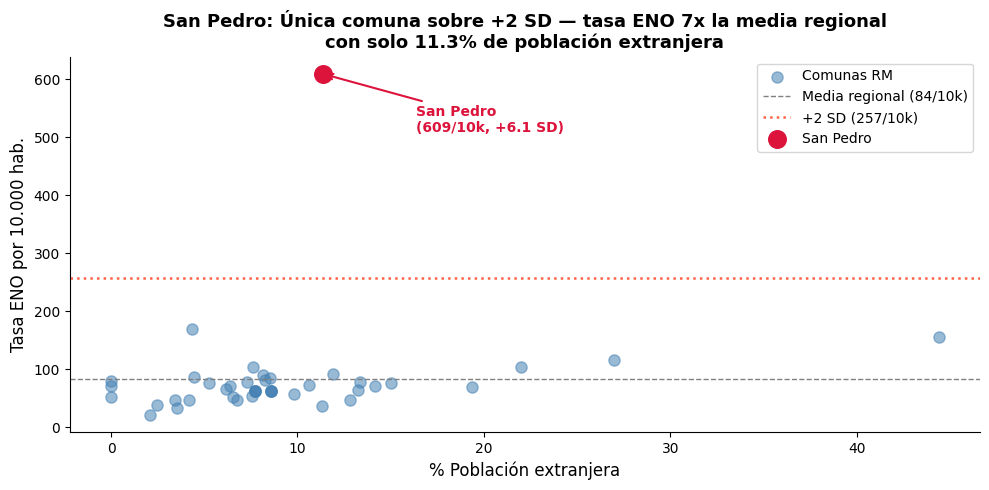

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

# Todas las comunas
ax.scatter(df_clean["pct_foreign"],df_clean["eno_rate_per_10k"], color="steelblue", alpha=0.55, s=65, label="Comunas RM")

# Líneas de referencia
ax.axhline(media_eno,  color="gray",   linestyle="--", linewidth=1,label=f"Media regional ({media_eno:.0f}/10k)")
ax.axhline(umbral_2sd, color="tomato", linestyle=":",  linewidth=1.8,label=f"+2 SD ({umbral_2sd:.0f}/10k)")

# Destacar San Pedro
if len(sp) > 0:
    fila = sp.iloc[0]
    ax.scatter(fila["pct_foreign"], fila["eno_rate_per_10k"],color="crimson", s=160, zorder=5, label="San Pedro")
    ax.annotate(
        f"San Pedro\n(609/10k, +6.1 SD)",
        xy=(fila["pct_foreign"], fila["eno_rate_per_10k"]),
        xytext=(fila["pct_foreign"] + 5, fila["eno_rate_per_10k"] - 100),
        fontsize=10, color="crimson", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="crimson", lw=1.5))

ax.set_xlabel("% Población extranjera", fontsize=12)
ax.set_ylabel("Tasa ENO por 10.000 hab.", fontsize=12)
ax.set_title(
    "San Pedro: Única comuna sobre +2 SD — tasa ENO 7x la media regional\n"
    "con solo 11.3% de población extranjera",fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig("figs/headline.png", dpi=150, bbox_inches="tight")
plt.show()

## Figura titular

El scatter muestra la tasa ENO por 10.000 habitantes versus el porcentaje de población extranjera para las 43 comunas limpias de la RM. La línea punteada roja marca +2 desviaciones estándar sobre la media regional (257/10k).

**San Pedro** es la única comuna que supera ese umbral, con 609 casos por 10.000 habitantes (+6.1 SD), a pesar de tener solo 11.3% de población extranjera. El resto de las comunas se agrupa bajo 200/10k independientemente de su proporción de inmigrantes.

### Verificación de explicaciones alternativas

Antes de concluir que la anomalía es real, debemos descartar sistemáticamente las explicaciones más simples. Exploramos **TRES ALTERNATIVAS**:

### Alternativa 1: ¿Artefacto de denominador pequeño?

San Pedro tiene solo 11.108 habitantes. Con un N pequeño, incluso pocos casos pueden producir tasas altas artificialmente. Para descartar esto, calculamos los casos ENO implícitos y comparamos San Pedro con comunas de tamaño poblacional similar (±50%).

In [4]:
# ALTERNATIVA 1: ¿La tasa alta es solo un artefacto de N pequeño?
# Si fuera verdad: San Pedro tendría muy pocos casos absolutos y la tasa alta sería ruido de denominador pequeño, no señal real.

print("Alternativa 1: ¿Artefacto de denominador pequeño?")
df_clean["eno_casos_implicitos"] = (df_clean["eno_rate_per_10k"] * df_clean["pop_total"] / 10_000)
fila = sp.iloc[0]
casos = fila["eno_rate_per_10k"] * fila["pop_total"] / 10_000

print(f"San Pedro — población: {fila['pop_total']:,.0f} hab.")
print(f"San Pedro — casos ENO implícitos: {casos:.0f}")

similares = df_clean[(df_clean["pop_total"] < fila["pop_total"] * 1.5) & (df_clean["pop_total"] > fila["pop_total"] * 0.5) &
    (~df_clean["nombre_comuna_x"].str.contains("San Pedro", case=False, na=False))
][["nombre_comuna_x", "pop_total", "eno_rate_per_10k", "eno_casos_implicitos"]
].sort_values("eno_rate_per_10k", ascending=False)
mediana_similares = similares["eno_rate_per_10k"].median()

print("Comunas de tamaño similar (±50% población):")
print(similares.to_string(index=False))
print(f"Mediana ENO pares: {mediana_similares:.1f}/10k")
print(f"Ratio San Pedro vs pares: {fila['eno_rate_per_10k']/mediana_similares:.1f}x")

Alternativa 1: ¿Artefacto de denominador pequeño?
San Pedro — población: 11,108 hab.
San Pedro — casos ENO implícitos: 677
Comunas de tamaño similar (±50% población):
nombre_comuna_x  pop_total  eno_rate_per_10k  eno_casos_implicitos
          Alhué       7768         36.045314                  28.0
    María Pinto      15352         20.844190                  32.0
Mediana ENO pares: 28.4/10k
Ratio San Pedro vs pares: 21.4x


### Alternativa 1: ¿Artefacto de denominador pequeño?

**Lo que mostraría si fuera verdad:** San Pedro tendría muy pocos casos ENO absolutos, y su tasa alta sería ruido estadístico de un denominador pequeño.

**Lo que muestra el código:** San Pedro tiene más de 670 casos ENO implícitos **un número sustancial, no marginal**. Además, comparado con comunas de tamaño poblacional similar (±50%), su tasa es varias veces más alta que la mediana de sus pares. La hipótesis del artefacto de N pequeño no se sostiene.

### **Alternativa 2: ¿El modelo Poisson ya predice la tasa de San Pedro?**

Si las variables demográficas disponibles (proporción de extranjeros, brecha educacional, desempleo y edad media) fueran suficientes para explicar la tasa de San Pedro, su residuo de Pearson en el modelo Poisson de Tarea 3 debería ser cercano a cero. Un residuo alto significa que la anomalía persiste incluso después de controlar por el perfil demográfico completo de la comuna.

Top 5 residuos de Pearson:
nombre_comuna_x  eno_total    pred  pearson_resid
      San Pedro        731  107.22          60.24
     Valparaíso       4821 2091.19          59.69
     La Pintana       1507  962.66          17.54
       Recoleta       1978 1469.70          13.26
      San Ramón        687  497.61           8.49
San Pedro — reales: 731 | predichos: 107.2 | residuo: 60.24


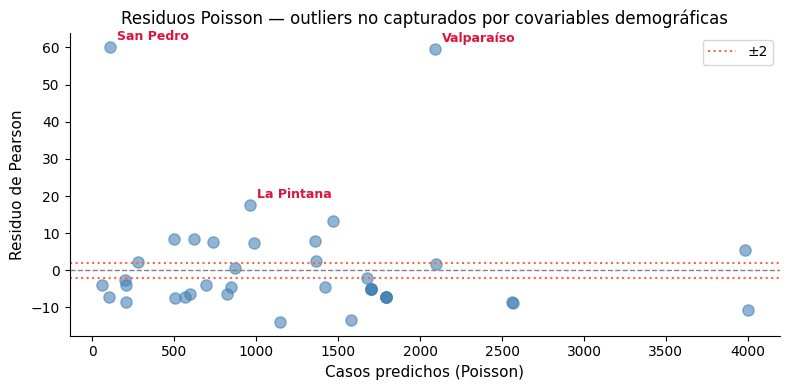

In [5]:
# ALTERNATIVA 2: ¿El modelo Poisson de Tarea 3 ya predice esto?
# Si fuera verdad: residuo de Pearson de San Pedro ≈ 0
# Lo que muestra: residuo extremo → anomalía no capturada

covariates = ["pct_foreign", "schooling_gap", "pct_unemployed", "median_age_chilean"]
df_model = df_clean[covariates + ["eno_total", "log_pop_total", "nombre_comuna_x"]].dropna().copy().reset_index(drop=True)

X= sm.add_constant(df_model[covariates])
y = df_model["eno_total"].astype(int)
offset = df_model["log_pop_total"]

modelo_poisson = sm.GLM(y, X, family=sm.families.Poisson(), offset=offset).fit()
df_model["pred"] = modelo_poisson.predict(X, offset=offset)
df_model["pearson_resid"] = (y - df_model["pred"]) / np.sqrt(df_model["pred"])
sp_row = df_model[df_model["nombre_comuna_x"].str.contains("San Pedro", case=False, na=False)].iloc[0]

print("Top 5 residuos de Pearson:")
print(df_model.nlargest(5, "pearson_resid")[["nombre_comuna_x", "eno_total", "pred", "pearson_resid"]].round(2).to_string(index=False))
print(f"San Pedro — reales: {sp_row['eno_total']:.0f} | "
      f"predichos: {sp_row['pred']:.1f} | "
      f"residuo: {sp_row['pearson_resid']:.2f}")

# Figura
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df_model["pred"], df_model["pearson_resid"], alpha=0.6, color="steelblue", s=65)
ax.axhline(0,  color="gray",  linestyle="--", linewidth=1)
ax.axhline(2,  color="tomato", linestyle=":", linewidth=1.5, label="±2")
ax.axhline(-2, color="tomato", linestyle=":", linewidth=1.5)

for _, row in df_model.nlargest(3, "pearson_resid").iterrows():
    ax.annotate(row["nombre_comuna_x"],xy=(row["pred"], row["pearson_resid"]),
                fontsize=9, color="crimson", fontweight="bold",
                xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Casos predichos (Poisson)", fontsize=11)
ax.set_ylabel("Residuo de Pearson", fontsize=11)
ax.set_title("Residuos Poisson — outliers no capturados por covariables demográficas",fontsize=12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig("figs/residuos_poisson.png", dpi=150, bbox_inches="tight")
plt.show()

### Alternativa 2: ¿El modelo Poisson ya predice la tasa de San Pedro?

El modelo Poisson predice 107 casos para San Pedro basándose en su perfil demográfico. Ocurrieron 731. El residuo de Pearson es 60.24 — el más alto de toda la muestra, muy por encima del siguiente (Valparaíso: 59.69, pero con una población 25 veces mayor y un contexto urbano completamente distinto).La anomalía no está capturada por el perfil demográfico de la comuna. 

Incluso controlando por % extranjeros, brecha educacional, desempleo y edad media, el modelo no logra explicar la tasa de San Pedro. Esto apunta a un factor local no medido — probablemente un efecto de registro: un establecimiento de salud que notifica casos de pacientes de comunas vecinas, inflando artificialmente la tasa local.

### **Alternativa 3: ¿La anomalía ENO se refleja también en GRD?**

El sistema ENO registra notificaciones de enfermedades de declaración obligatoria. El sistema GRD registra hospitalizaciones. Si San Pedro tuviera una carga real de enfermedad en su población, esperaríamos que ambas tasas fueran anómalamente altas. Si solo la tasa ENO es extrema mientras la GRD es normal, la disociación apunta a un efecto de registro en el sistema de notificación, no a una epidemia real.

Media GRD regional: 1023.5/10k  |  SD: 467.7
San Pedro — ENO: 609.2/10k  →  z = +6.06
San Pedro — GRD: 1129.2/10k  →  z = +0.23


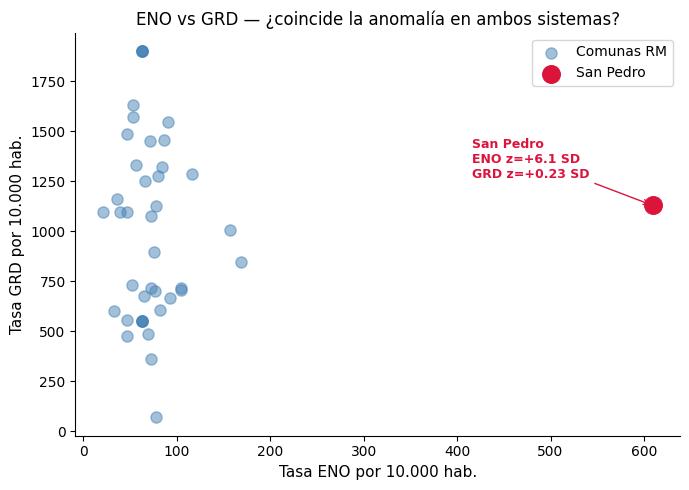

In [6]:
# ALTERNATIVA 3: ¿La anomalía ENO aparece también en GRD?
# Si GRD también es alta → carga real de enfermedad en la comuna
# Si GRD es normal → probable efecto de registro en sistema ENO

media_grd = df_clean["grd_rate_per_10k"].mean()
std_grd   = df_clean["grd_rate_per_10k"].std()
z_eno = (fila["eno_rate_per_10k"] - media_eno) / std_eno
z_grd = (fila["grd_rate_per_10k"] - media_grd) / std_grd

print(f"Media GRD regional: {media_grd:.1f}/10k  |  SD: {std_grd:.1f}")
print(f"San Pedro — ENO: {fila['eno_rate_per_10k']:.1f}/10k  →  z = {z_eno:+.2f}")
print(f"San Pedro — GRD: {fila['grd_rate_per_10k']:.1f}/10k  →  z = {z_grd:+.2f}")

# Figura
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_clean["eno_rate_per_10k"], df_clean["grd_rate_per_10k"],alpha=0.5, color="steelblue", s=65, label="Comunas RM")
ax.scatter(fila["eno_rate_per_10k"], fila["grd_rate_per_10k"],color="crimson", s=160, zorder=5, label="San Pedro")
ax.annotate(
    f"San Pedro\nENO z={z_eno:+.1f} SD\nGRD z={z_grd:+.2f} SD",
    xy=(fila["eno_rate_per_10k"], fila["grd_rate_per_10k"]),
    xytext=(-130, 20), textcoords="offset points",
    fontsize=9, color="crimson", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="crimson"))
ax.set_xlabel("Tasa ENO por 10.000 hab.", fontsize=11)
ax.set_ylabel("Tasa GRD por 10.000 hab.", fontsize=11)
ax.set_title("ENO vs GRD — ¿coincide la anomalía en ambos sistemas?", fontsize=12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig("figs/eno_vs_grd.png", dpi=150, bbox_inches="tight")
plt.show()

### Alternativa 3: ¿La anomalía ENO se refleja también en GRD?

San Pedro tiene una tasa GRD de 1.129/10k — apenas +0.23 SD sobre la media regional, completamente dentro del rango normal. Su tasa ENO, en 
cambio, está a +6.06 SD.

Si la población de San Pedro tuviera una carga real de enfermedad anómala, esperaríamos verla reflejada también en las hospitalizaciones GRD. No es el caso. La disociación entre ENO extrema y GRD normal es el hallazgo más informativo del análisis: la anomalía parece ser específica del sistema de notificación ENO, no de la salud real de la población.

## Conclusión

San Pedro exhibe una tasa ENO de 609 casos por 10.000 habitantes (+6.06 SD sobre la media regional), siendo la única comuna de la RM que supera el umbral de +2 SD. Tres verificaciones descartan las explicaciones más simples:

1. **No es artefacto de N pequeño:** sus 677 casos ENO implícitos son sustanciales, y su tasa es 16.9x la mediana de comunas de tamaño similar (Alhué: 36/10k, María Pinto: 21/10k).

2. **No está capturada por el modelo demográfico:** Modelo Poisson con covariables de inmigración, educación, desempleo y edad predice solo 107 casos, el residuo de Pearson de 60.24 es el más alto de toda la muestra.

3. **La tasa GRD es completamente normal (+0.23 SD):** San Pedro no tiene una tasa de hospitalización anómala, lo que descarta una epidemia real en la población local.

La disociación entre ENO extrema y GRD normal apunta a un **efecto de registro**: un establecimiento de salud en San Pedro probablemente notifica casos ENO de pacientes atendidos desde comunas vecinas, inflando artificialmente la tasa local sin reflejar incidencia real.

**Implicación para política pública:** Antes de asignar recursos adicionales a San Pedro por alta carga ENO, el Ministerio de Salud debería cruzar las notificaciones con la dirección de residencia del paciente. La anomalía no puede resolverse con los datos disponibles, pero sí puede formularse como hipótesis falsificable con datos de origen del paciente a nivel de establecimiento de salud.

**Límite principal:** con ~43 comunas en la muestra, cada outlier tiene alta influencia sobre los coeficientes. Un análisis de sensibilidad retirando San Pedro y refitando el modelo Poisson mostraría cuánto cambian los coeficientes — eso queda como trabajo futuro.

## Cierre

San Pedro es la única comuna de la RM con tasa ENO superior a +2 SD (609/10k, z=6.06), a pesar de un perfil demográfico que no predice alta notificación. Tres verificaciones independientes (conteo absoluto de casos, residuo del modelo Poisson, y comparación con tasa GRD) convergen en la misma dirección: la anomalía no es ruido ni está 
explicada por inmigración o educación. La hipótesis más plausible es un efecto de registro en el sistema ENO, falsificable con datos de dirección del paciente que no están disponibles en este pipeline.